In [17]:
#%pip install openpyxl

Para el excel del mercado laboral

In [18]:
#%pip install xlrd
#%pip install seaborn

In [19]:
import pandas as pd
import json
import os
from typing import Dict, Union
import seaborn as sns

#Limpieza de datos
from limpieza.votos import limpieza_votos_partidos
from limpieza.rentas import procesar_archivo_ine, procesar_archivo_gini, procesar_fuente_ingresos
from limpieza.paro_contratos import limpiar_y_exportar_sepe
from limpieza.superficie import procesar_geografia_municipios
from limpieza.poblacion import procesar_poblacion_maestro
from limpieza.funciones_genericas_limpieza import leer_json, leer_archivo_csv

#EDA
from EDA.demografia_superficie import eda_demografia_superficie
from EDA.mercado_laboral import eda_mercado_laboral
from EDA.desigualdad_renta import gestion_nulos_desigualdad, eda_gini_p80p20
from EDA.fuente_ingresos_renta import eda_fuente_ingresos
from EDA.indicadores_renta import eda_indicadores_renta, visualizar_histogramas_renta

# Función ETL limpieza
Creamos una función la cual segun los años nos crea el listado de bases datos a gtraves de procesar los datos en sucio y transformarlos en data limpia.

In [20]:
def ETL_limpieza(year: Union[int, str], config_path: str = "config_path.json") -> Dict[str, pd.DataFrame]:
    """
    Función orquestadora ETL de los archivos de la carpeta "limpieza".
    Orquesta la ejecución de funciones individuales de limpieza, gestiona la 
    caché según el estado de los archivos y carga los resultados 
    en memoria inyectándolos como variables globales.
    Args:
        year (Union[int, str]): Año objetivo para procesar los datos.
        config_path (str, optional): Ruta al archivo JSON de configuración. Por defecto "config_path.json".
    Returns:
        Dict[str, pd.DataFrame]: Diccionario con los DataFrames instanciados.
    Raises:
        ValueError: Si el año proporcionado no está definido en el config.
    """
    year_str = str(year)
    
    # Lectura del JSON de configuración usando nuestra función genérica
    config = leer_json(config_path)
        
    if year_str not in config:
        raise ValueError(f"El año {year_str} no existe en el archivo {config_path}.")
        
    raw_paths = config[year_str]["raw"]
    proc_paths = config[year_str]["processed"]
    
    dataframes: Dict[str, pd.DataFrame] = {}
        
    for clave, ruta_procesada in proc_paths.items():
        nombre_df = f"df_{year_str}_{clave}"
        es_carpeta = "carpeta" in clave.lower()
        
        ya_procesado = False
        archivos_votos_esperados = []
        
        if clave == "carpeta_votos":
            archivos_votos_esperados = [
                f"arbol_candidaturas_{year_str}.json",
                f"candidaturas_ideologia_{year_str}.json",
                f"maestro_ideologia_{year_str}.json",
                f"Votos_Agrupados_Padres_{year_str}.csv",
                f"Votos_Granularidad_Total_{year_str}.csv"
            ]
            if os.path.exists(ruta_procesada):
                ya_procesado = all(
                    os.path.exists(os.path.join(ruta_procesada, arch)) 
                    for arch in archivos_votos_esperados
                )
        else:
            ya_procesado = os.path.exists(ruta_procesada)
            
        if not ya_procesado:
            if es_carpeta:
                os.makedirs(ruta_procesada, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(ruta_procesada), exist_ok=True)
            
            try:
                if clave in ["poblacion_csv", "poblacion_json"]:
                    ruta_json = proc_paths["poblacion_json"]
                    ruta_csv = proc_paths["poblacion_csv"]
                    if not (os.path.exists(ruta_json) and os.path.exists(ruta_csv)):
                        procesar_poblacion_maestro(
                            path_lectura=raw_paths["poblacion"],
                            path_salida_json=ruta_json,
                            path_salida_csv=ruta_csv
                        )
                
                elif clave == "paro_contratos":
                    limpiar_y_exportar_sepe(raw_paths["paro_contratos"], ruta_procesada)
                    
                elif clave == "geografia":
                    procesar_geografia_municipios(raw_paths["geografia"], ruta_procesada)
                    
                elif clave == "carpeta_votos":
                    limpieza_votos_partidos(
                        fichero_cis=raw_paths["ideologias"],
                        fichero_03=raw_paths["votos_candidaturas"],
                        fichero_06=raw_paths["Votos_candidaturas_agrupados"],
                        ruta_guardado=ruta_procesada,
                        anio=year_str
                    )
                    
                elif clave == "renta_disponible":
                    procesar_archivo_ine(raw_paths["renta_disponible"], ruta_procesada)
                    
                elif clave == "GINI_P80P20":
                    procesar_archivo_gini(raw_paths["GINI_P80P20"], ruta_procesada)
                    
                elif clave == "fuente_ingresos":
                    procesar_fuente_ingresos(raw_paths["fuente_ingresos"], ruta_procesada)
                    
            except Exception as e:
                print(f"Error al procesar '{clave}': {e}")

        # --- CARGA DE DATOS EN MEMORIA ---
        if not es_carpeta:
            if os.path.exists(ruta_procesada):
                try:
                    if ruta_procesada.endswith('.csv'):
                        # SOLUCIÓN: decimal='.' para los archivos procesados
                        dataframes[nombre_df] = leer_archivo_csv(ruta_procesada, decimal='.')
                    elif ruta_procesada.endswith('.json'):
                        # Mantenemos pd.read_json para cargar directamente como DataFrame
                        dataframes[nombre_df] = pd.read_json(ruta_procesada)
                except Exception as e:
                    print(f"Error al cargar archivo '{nombre_df}': {e}")
                    
        elif clave == "carpeta_votos":
            for archivo in archivos_votos_esperados:
                ruta_archivo = os.path.join(ruta_procesada, archivo)
                
                if os.path.exists(ruta_archivo):
                    nombre_sin_ext = os.path.splitext(archivo)[0]
                    nombre_df_carpeta = f"df_{year_str}_{nombre_sin_ext}"
                    
                    try:
                        if archivo.endswith('.csv'):
                            # SOLUCIÓN: decimal='.' para los archivos de la carpeta procesada
                            dataframes[nombre_df_carpeta] = leer_archivo_csv(ruta_archivo, decimal='.')
                        elif archivo.endswith('.json'):
                            # Mantenemos pd.read_json para cargar directamente como DataFrame
                            dataframes[nombre_df_carpeta] = pd.read_json(ruta_archivo)
                    except Exception as e:
                        print(f"Error al cargar el archivo '{archivo}': {e}")
                        
    print(f"\nETL COMPLETADO ({year_str})")
    print("DataFrames generados y listos como variables:")
    for df_name in dataframes.keys():
        print(f"{df_name}")
        
    globals().update(dataframes)
    
    return dataframes

In [21]:
#dataframes = ETL_limpieza(2023, "config_path.json")

In [22]:
dataframes_2019 = ETL_limpieza(2019, "config_path.json")


ETL COMPLETADO (2019)
DataFrames generados y listos como variables:
df_2019_arbol_candidaturas_2019
df_2019_candidaturas_ideologia_2019
df_2019_maestro_ideologia_2019
df_2019_Votos_Agrupados_Padres_2019
df_2019_Votos_Granularidad_Total_2019
df_2019_renta_disponible
df_2019_GINI_P80P20
df_2019_fuente_ingresos
df_2019_paro_contratos
df_2019_geografia
df_2019_poblacion_json
df_2019_poblacion_csv


In [23]:
df_2019_renta_disponible.head()

,Cod_Muni,Nombre_Muni,Media de la renta por unidad de consumo 2015,Media de la renta por unidad de consumo 2016,Media de la renta por unidad de consumo 2017,Media de la renta por unidad de consumo 2018,Media de la renta por unidad de consumo 2019,Media de la renta por unidad de consumo 2020,Media de la renta por unidad de consumo 2021,Media de la renta por unidad de consumo 2022,...,Renta neta media por hogar 2023,Renta neta media por persona 2015,Renta neta media por persona 2016,Renta neta media por persona 2017,Renta neta media por persona 2018,Renta neta media por persona 2019,Renta neta media por persona 2020,Renta neta media por persona 2021,Renta neta media por persona 2022,Renta neta media por persona 2023
0,1001,Alegría-Dulantzi,NaN,NaN,NaN,NaN,NaN,20982.750000,21797.250000,22456.000000,...,41764.75,12936.0,13086.0,13281.0,13361.0,14299.0,13987.750000,14664.25,15129.000000,16449.000000
1,1002,Amurrio,NaN,NaN,NaN,NaN,NaN,21503.111111,22239.777778,23339.555556,...,42360.00,13800.0,13691.0,13862.0,14103.0,14892.0,14495.666667,15051.00,15841.666667,17291.666667
2,1003,Aramaio,NaN,NaN,NaN,NaN,NaN,27943.000000,27784.000000,30265.000000,...,52084.00,15786.0,17194.0,16177.0,16478.0,18177.0,18386.000000,18440.00,20201.000000,20577.000000
3,1004,Artziniega,NaN,NaN,NaN,NaN,NaN,19911.000000,20836.000000,23170.000000,...,39945.00,12722.0,13185.0,12530.0,13157.0,13622.0,13335.000000,14033.00,15651.000000,16408.000000
4,1006,Armiñón,NaN,NaN,NaN,NaN,NaN,20507.000000,23594.000000,22659.000000,...,42042.00,13040.0,11330.0,13115.0,14671.0,15531.0,14278.000000,16927.00,15755.000000,17000.000000


# EDA 2019
PAra esto planteo fases y objetivos para no perder la idea durante el proceso

## Fase 1: Análisis de "Salud" y Distribución (Univariante)
En esta fase analizamos cada fichero por separado. Trabajaremos con los datos de 2019.

### 1.1. Demografía y Superficie, contexto físico
* Calcular la Densidad de Población (población_total / superficie_km2).

RESUMEN DEMOGRÁFICO
Población total: 47,026,208 habitantes



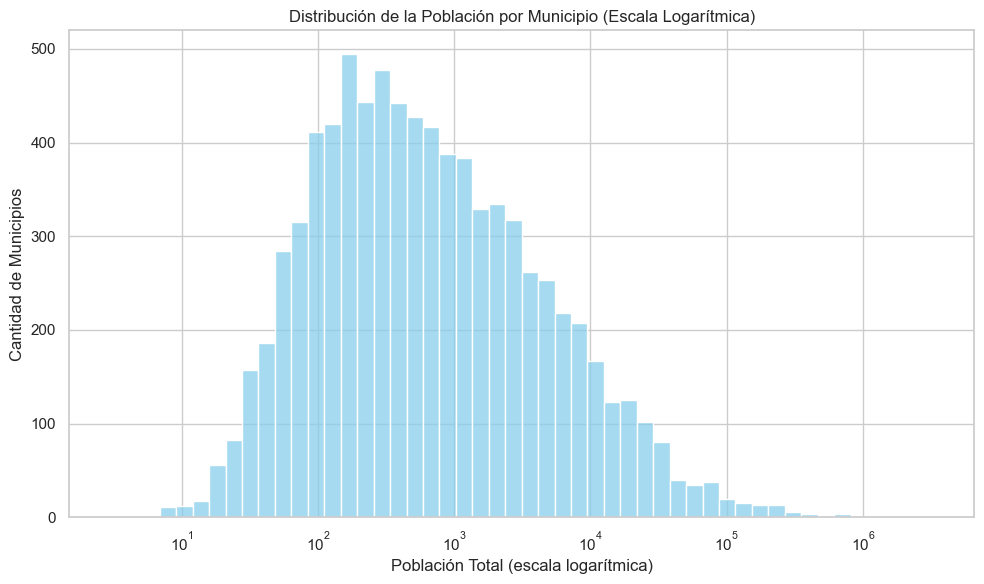

10 MUNICIPIOS MÁS POBLADOS
 1. Madrid                         |  3,266,126 habs.
 2. Barcelona                      |  1,636,762 habs.
 3. València                       |    794,288 habs.
 4. Sevilla                        |    688,592 habs.
 5. Zaragoza                       |    674,997 habs.
 6. Málaga                         |    574,654 habs.
 7. Murcia                         |    453,258 habs.
 8. Palma                          |    416,065 habs.
 9. Palmas de Gran Canaria, Las    |    379,925 habs.
10. Bilbao                         |    346,843 habs.

10 MUNICIPIOS MENOS POBLADOS
 1. Illán de Vacas                 |          3 habs.
 2. Villarroya                     |          5 habs.
 3. Jaramillo Quemado              |          7 habs.
 4. Arandilla del Arroyo           |          7 habs.
 5. Valtablado del Río             |          7 habs.
 6. Estepa de San Juan             |          7 habs.
 7. Castilnuevo                    |          8 habs.
 8. Valdemadera          

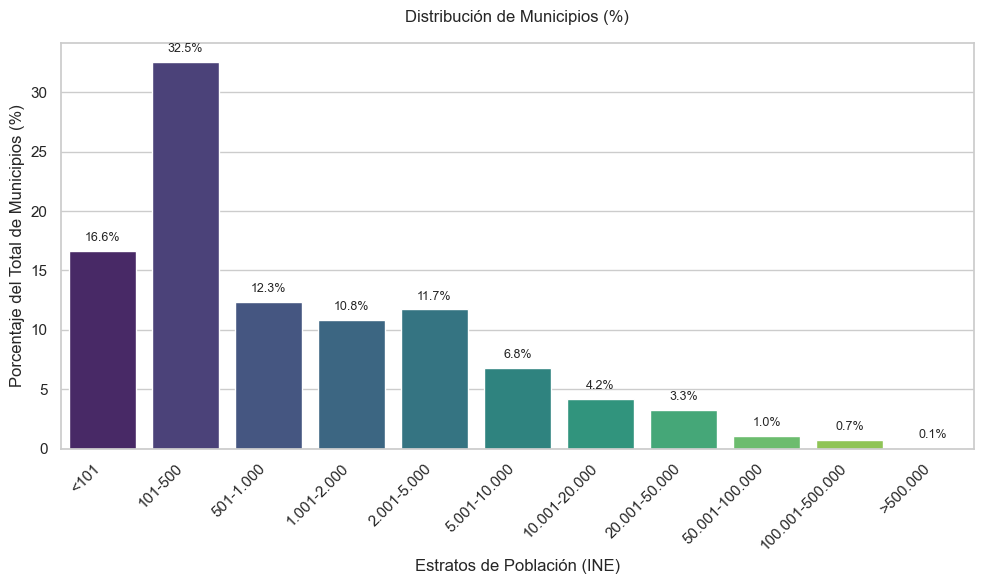

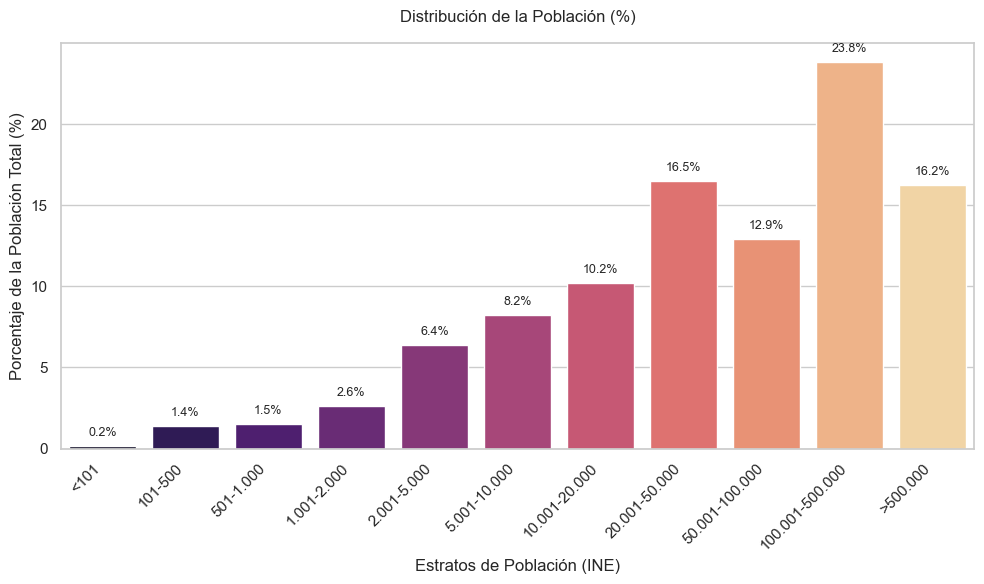

CONTROL DE CALIDAD GEOGRÁFICO
Densidad media nacional: 93.17 hab/km2
Municipios con superficie 0 o negativa: 0
Municipios con latitud fuera de rango: 0
Municipios con longitud fuera de rango: 0


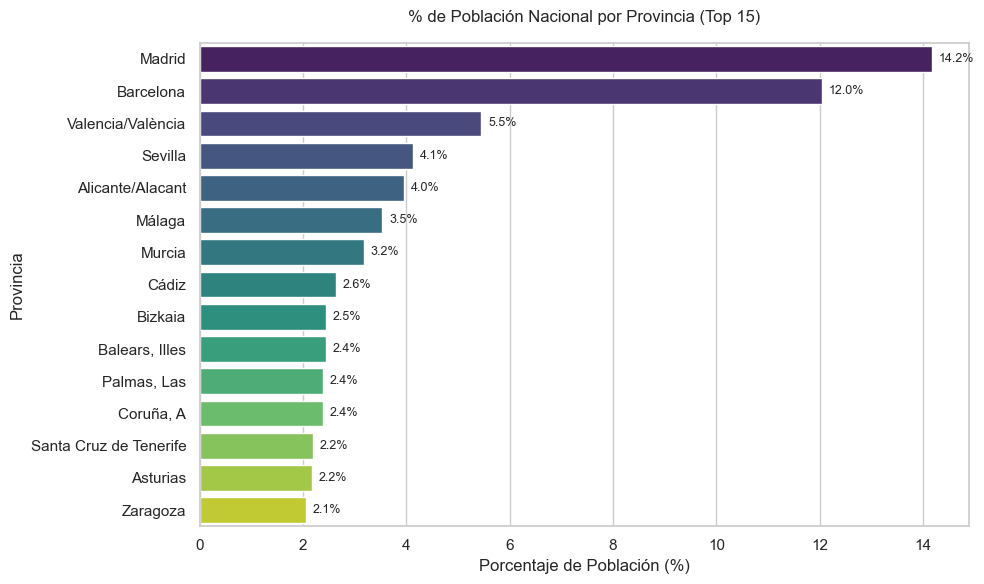

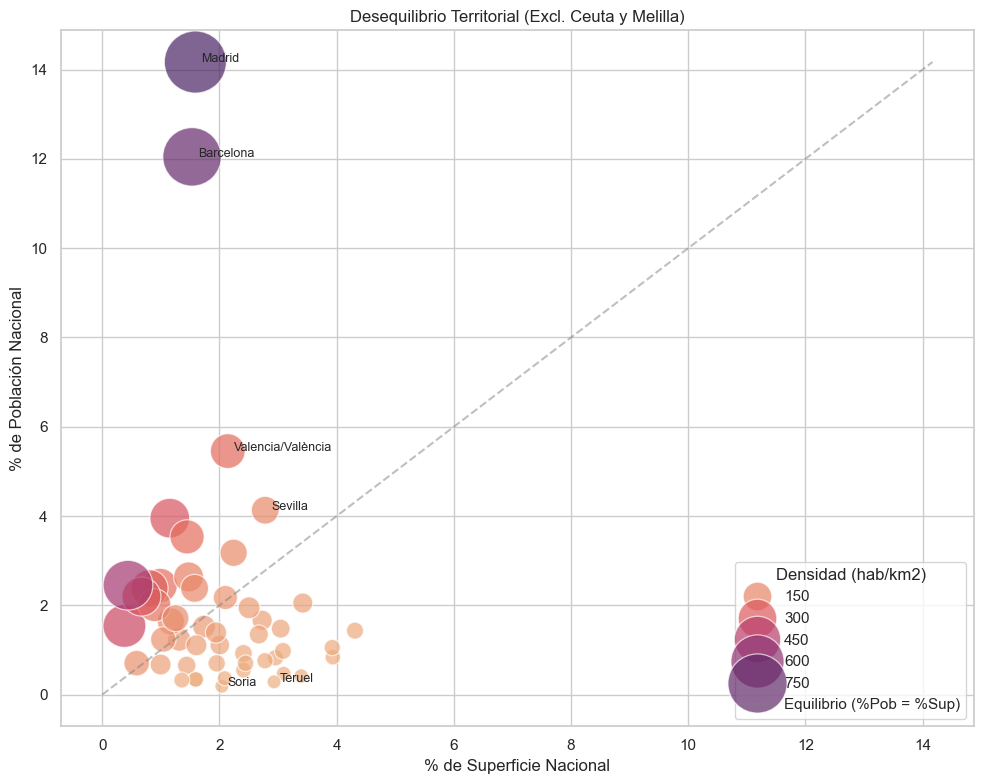

RESUMEN ESTADÍSTICO: CIUDADES AUTÓNOMAS (Excluidas del gráfico por densidad extrema)
- Ceuta: 84,777 hab | 19.87 km2 | Densidad: 4,266.58 hab/km2
- Melilla: 86,487 hab | 14.24 km2 | Densidad: 6,072.33 hab/km2


In [24]:
df_poblacion_superficie_2019 = eda_demografia_superficie(df_pob=df_2019_poblacion_csv, data_json=df_2019_poblacion_json, df_sup=df_2019_geografia)

Al hacer un primer análisis de los municipios y de cómo está distribuida la población española en 2019, podemos observar un fuerte contraste: los municipios con menos de 500 habitantes representan el 49,1% del total de municipios del Estado español, pero agrupan únicamente al 1,6% de la población. Por el contrario, los grandes municipios (aquellos de más de 100.000 habitantes) representan apenas el 0,8% de los ayuntamientos, pero concentran al 40% de la población. Destaca especialmente que la mayor acumulación demográfica se da en las ciudades de entre 100.000 y 500.000 habitantes, que por sí solas agrupan al 23,8% del total nacional.

Al observar el histograma de la distribución de la población, vemos que la mayor concentración de municipios se encuentra entre $10^2$ y $10^3$ en el eje X, lo que corresponde a poblaciones de entre 100 y 1.000 habitantes. En una escala lineal, esta variable presenta una fuerte asimetría con un marcado sesgo positivo (una larga cola hacia la derecha debido a unas pocas ciudades gigantes). Sin embargo, al aplicar la escala logarítmica, comprobamos que los datos adoptan una forma de campana, lo que indica que la población municipal en España sigue una distribución estadística log-normal.

Por último, si analizamos los extremos, vemos una enorme brecha demográfica. Los seis municipios más poblados del país superan el medio millón de habitantes, en un top 10 encabezado por Madrid (con 3.266.126 habitantes) y que cierra Bilbao en décima posición con más de 340.000 vecinos. En su contraparte, los 10 municipios menos poblados no logran superar los 8 habitantes. El municipio con menor población es Illán de Vacas, con únicamente 3 personas empadronadas, mientras que Villanueva de Gormaz marca el límite de este top 10 por abajo con 8 habitantes (un puesto que comparte con varios municipios más en esa misma situación).


Posteriormente, al trasladar el análisis al nivel provincial, se observa que Madrid y Barcelona se consolidan como los grandes polos demográficos, acumulando por sí solas el 26,2% de la población nacional. El diagrama de dispersión (scatterplot) aporta una perspectiva clave sobre este fenómeno mediante tres variables:

* Densidad Poblacional: Representada por el tamaño de las esferas, permite identificar visualmente la concentración de habitantes por kilómetro cuadrado, destacando de nuevo a las provincias de Madrid y Barcelona.

* Línea de Equilibrio (Bisectriz): Esta línea discontinua representa una distribución teórica ideal donde el peso demográfico de una provincia equivale a su peso territorial.

* Identificación de Desequilibrios: Las provincias situadas por debajo de la línea (como Soria o Teruel) muestran un claro desequilibrio territorial: poseen un alto porcentaje de superficie pero una baja carga demográfica. Al tener garantizado por ley un mínimo de dos escaños en el Congreso, estas provincias presentan una sobrerrepresentación electoral en relación con su censo.

En este análisis, se ha optado por excluir a las ciudades autónomas de Ceuta y Melilla del gráfico de dispersión. Al tratarse de entornos puramente urbanos con superficies muy reducidas, sus densidades extremas distorsionaban la escala visual del resto de provincias; no obstante, su peso ha sido documentado estadísticamente por separado. Por el contrario, las provincias situadas por encima de la línea (aquellas con mayor concentración de habitantes) sufren una subrepresentación, ya que, aunque eligen un mayor número de diputados, reciben menos de los que les corresponderían en un sistema de reparto estrictamente proporcional sin mínimos territoriales.


**Conclusiones: Impacto en el Sistema Electoral y la Ley D'Hondt**

Esta polarización demográfica es la raíz de la desproporcionalidad electoral en España. Al utilizar la provincia como circunscripción y asignar un mínimo de dos escaños fijos a cada una, el sistema transfiere peso político desde las urbes hacia el territorio.

La gran masa de municipios de menos de 500 habitantes (el 49,1% del total nacional) da lugar a provincias extensas pero poco pobladas, ubicadas bajo la línea de equilibrio, que actúan como circunscripciones pequeñas. En estas zonas, la fórmula D'Hondt agudiza el sesgo: al repartirse pocos escaños (2 o 3), el "precio" del diputado en votos es mucho más bajo, pero los partidos minoritarios quedan excluidos al no alcanzar los altos umbrales necesarios.

En consecuencia, el diseño actual otorga un peso electoral desproporcionado a las áreas rurales frente a los grandes núcleos urbanos (que concentran al 40% de la población en solo el 0,8% de los municipios), rompiendo la máxima de "un persona, un voto" en favor de la representación territorial.

*NOTA: las franjas para separar la población han sido basadas en como el INE separa las provincias según el padron: "https://www.ine.es/jaxiPx/Tabla.htm?path=/t20/e245/p04/a2002/l0/&file=000an001.px&L=0"*

### 1.2. Mercado Laboral (La salud del empleo)

* Sectores: ¿En cuántos municipios domina el sector servicios (p_ser) frente al agrario (p_agr)?
* Brecha: Compara total_paro de hombres vs mujeres.

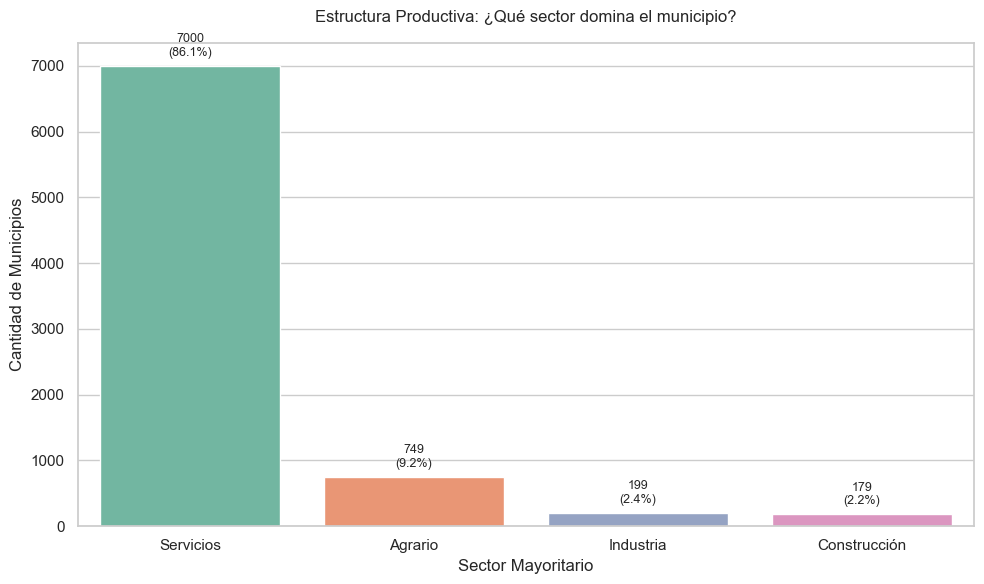

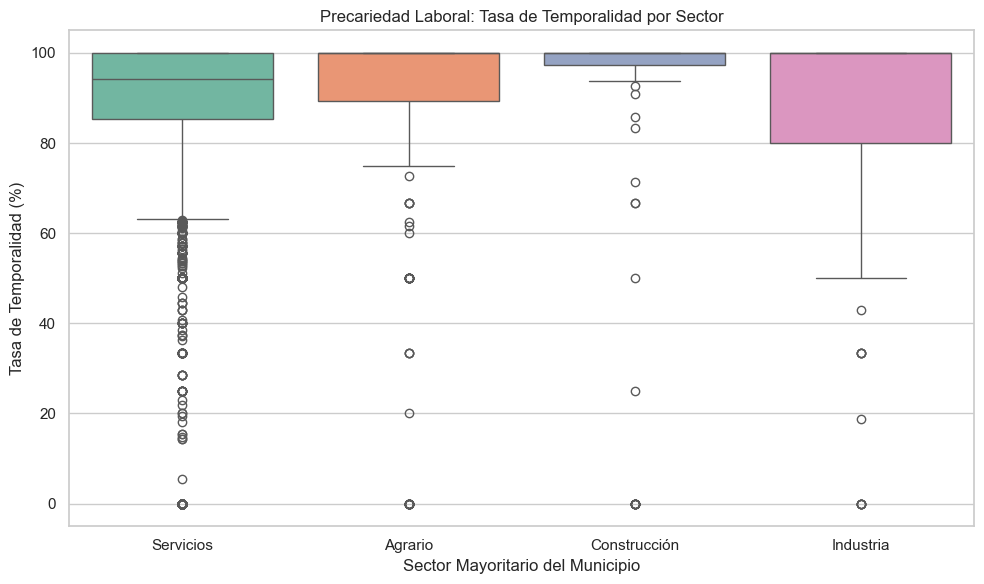

RADIOGRAFÍA DEL MERCADO LABORAL
Temporalidad real nacional (ponderada): 90.3% de los contratos
Peso medio del paro Femenino: 54.2% del total de parados
Peso medio del paro Juvenil (<25): 7.6% del total de parados
Peso medio del paro Senior (>45): 56.3% del total de parados

MÉTRICAS ESTRUCTURALES Y BRECHAS


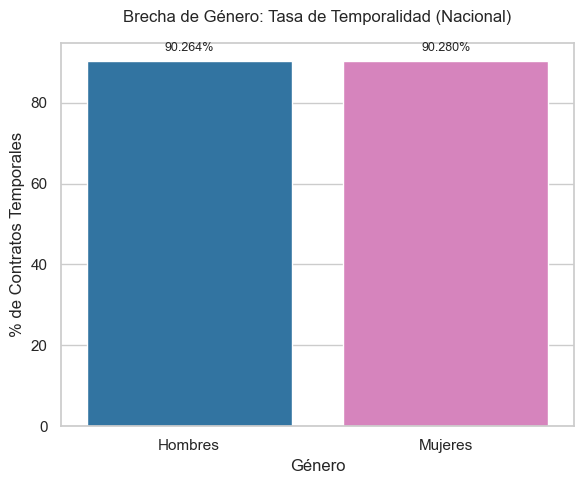

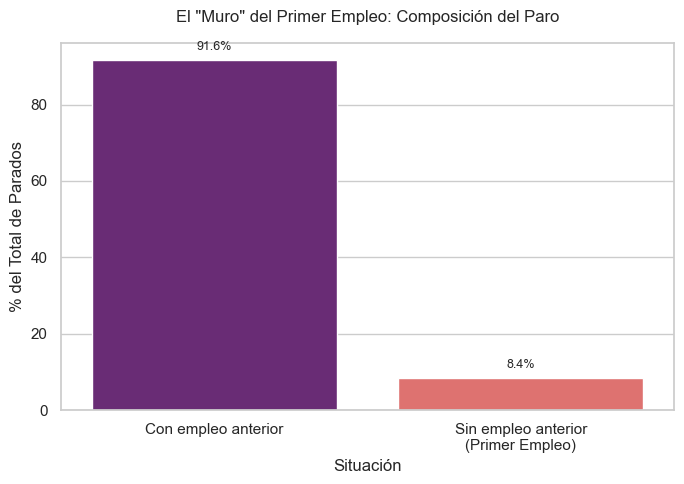

PRIMER EMPLEO: 269,615 parados (8.4% del total nacional) nunca han trabajado.


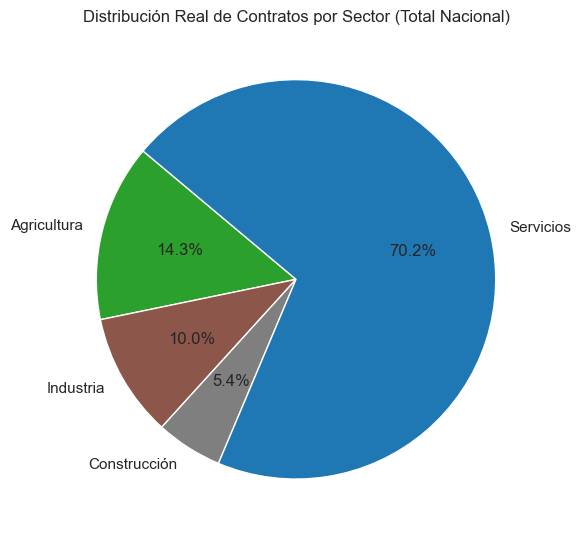

ESTRUCTURA DE CONTRATACIÓN NACIONAL:
Agricultura: 253,072 contratos
Industria: 176,832 contratos
Construcción: 95,032 contratos
Servicios: 1,238,712 contratos


In [25]:
df_mercado_laboral = eda_mercado_laboral(df_paro_contratos = df_2019_paro_contratos)

Los datos analizados corresponden a noviembre de 2019, mes en el que se celebraron las elecciones generales. En cuanto a la estructura de contratación, el sector servicios actúa como el motor principal, representando el 70,2% de los contratos a nivel nacional y consolidándose como el sector mayoritario en 7.000 municipios. Le sigue el sector agrícola, con un 14,3% de los contratos y siendo la principal fuente de empleo en 749 municipios. En tercer lugar, el sector industrial representa el 10% de las firmas, liderando la contratación en 199 localidades. Finalmente, con una presencia territorial similar a la industria pero menor volumen, la construcción agrupa el 5,4% de los contratos, siendo el sector dominante en apenas 179 municipios.

La tasa media de temporalidad nacional en este mes se sitúa en un altísimo 90,3%, al igual que la brecha por genero. Esta cifra, aunque elevada, responde fielmente al contexto socioeconómico del momento: noviembre marca el inicio de las contrataciones estacionales masivas para el Black Friday y la campaña de Navidad. Además, el mercado operaba bajo el marco legal previo a la reforma laboral de 2021, que posteriormente limitaría la contratación eventual, por lo que estas cifras reflejan la precariedad estructural de la época.

Al analizar la demografía del desempleo, se observan claras brechas. El peso medio del paro femenino asciende al 54,2% del total de desempleados. Sin embargo, el colectivo más afectado de forma estructural es el de los trabajadores sénior (mayores de 45 años), quienes suponen el 56,3% de los parados totales. En contraparte, los jóvenes menores de 25 años representan un peso medio del 7,6%. Adicionalmente, los datos revelan una fuerte barrera de entrada al mercado: 269.615 personas, el 8,4% de los parados del país, son demandantes de su primer empleo y nunca han cotizado previamente.

Por último, el análisis de dispersión (boxplot) de la temporalidad por sectores revela dinámicas muy distintas. La construcción presenta una menor dispersión en sus tasas de temporalidad, indicando un comportamiento más homogéneo en todo el país. La industria, en cambio, muestra una mayor variabilidad. Destaca especialmente el sector servicios, que acumula la mayor cantidad de valores atípicos (outliers), lo que evidencia realidades laborales extremadamente polarizadas dependiendo de la vocación turística o comercial de cada municipio.

### 1.3. Renta e Igualdad (El motor económico)
Acción: Filtrar solo las columnas de 2019.

Análisis:
* Indicador Clave: Usa Renta neta media por persona 2019. Mira su media y desviación estándar.
* Desigualdad: Analiza el Índice de Gini 2019. Un Gini alto (>35) indica mucha desigualdad. Mira si esos municipios coinciden con las rentas más altas o bajas.
* Dependencia: Calcula qué porcentaje de los ingresos viene de salario 2019 vs pensiones 2019.

Empezamos por el indice de GINI y el P80P20, tenemos que tener en cuenta que el ine no publica datos de los municipios de menos de 500 habitantes por secretos estadisticos, ademas Pais vasco y Navarra tienen regimenes forales propios por lo que puede faltar información. 


AUDITORÍA DE DATOS FALTANTES DESIGUALDAD (2019)
Total de municipios en el dataset: 8139
Nulos en Gini:      1693 municipios (20.8% del total)
Nulos en P80/P20:   1693 municipios (20.8% del total)


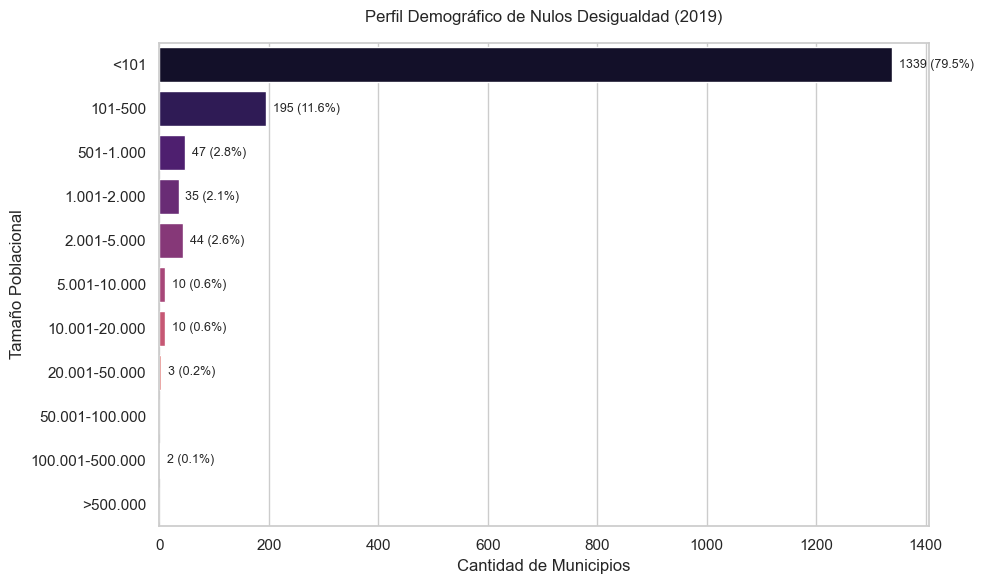


IMPACTO POR PROVINCIA Desigualdad (2019)
Top 10 provincias con más nulos Desigualdad:
 - Navarra             :  272 municipios (16.1%)
 - Guadalajara         :  182 municipios (10.8%)
 - Burgos              :  171 municipios (10.1%)
 - Soria               :  118 municipios (7.0%)
 - Ávila               :  100 municipios (5.9%)
 - Teruel              :   96 municipios (5.7%)
 - Zaragoza            :   88 municipios (5.2%)
 - Salamanca           :   87 municipios (5.2%)
 - Segovia             :   79 municipios (4.7%)
 - Cuenca              :   78 municipios (4.6%)

ANÁLISIS DE EXCEPCIONES AL SECRETO ESTADÍSTICO (<= 100 hab. en 2019)
Se han encontrado 13 municipios con datos a pesar de su pequeño tamaño (<= 100 hab).

RESUMEN DE EXCEPCIONES POR PROVINCIA:
 - Guadalajara: 2 municipio(s)
 - Cáceres: 1 municipio(s)
 - Castellón/Castelló: 1 municipio(s)
 - Cuenca: 1 municipio(s)
 - Huesca: 1 municipio(s)
 - Lleida: 1 municipio(s)
 - Salamanca: 1 municipio(s)
 - Soria: 1 municipio(s)
 - Tarra

In [26]:
gestion_nulos_desigualdad(df_gini = df_2019_GINI_P80P20, df_pob= df_poblacion_superficie_2019, anyo="2019")

En primer lugar, observamos que hay ocho municipios que ya no existen, lo cual se debe a que fueron fusionados con otros en el pasado. Por otro lado, Navarra presenta valores nulos en todos sus municipios; este es un punto clave de análisis dada su condición de comunidad foral uniprovincial. Asimismo, la norma de omitir datos en municipios con una población igual o inferior a 100 habitantes se incumple en 13 casos, una muestra demasiado pequeña para extrapolar los resultados al resto de las localidades.

 INICIANDO ANÁLISIS DE DESIGUALDAD Y RENTA (2019)
Info: 1693 de 8139 municipios NO tienen datos de renta en 2019.

TOP 10 MUNICIPIOS MÁS DESIGUALES (2019)
 1. Benasau                   | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 2. Mediana de Voltoya        | Gini: 45.2 | Los ricos ganan 3.6x más que los pobres
 3. Carataunas                | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 4. Alocén                    | Gini: 45.2 | Los ricos ganan 2.7x más que los pobres
 5. Guadramiro                | Gini: 45.2 | Los ricos ganan 2.3x más que los pobres
 6. Villarluengo              | Gini: 45.2 | Los ricos ganan 4.6x más que los pobres
 7. Campillo de Ranas         | Gini: 44.9 | Los ricos ganan 4.2x más que los pobres
 8. Villardondiego            | Gini: 44.9 | Los ricos ganan 2.9x más que los pobres
 9. Pobla de Benifassà, la    | Gini: 44.6 | Los ricos ganan 3.0x más que los pobres
10. Sant Mori                 | Gini: 44.0 | Los ricos ganan 2.3x más que los po

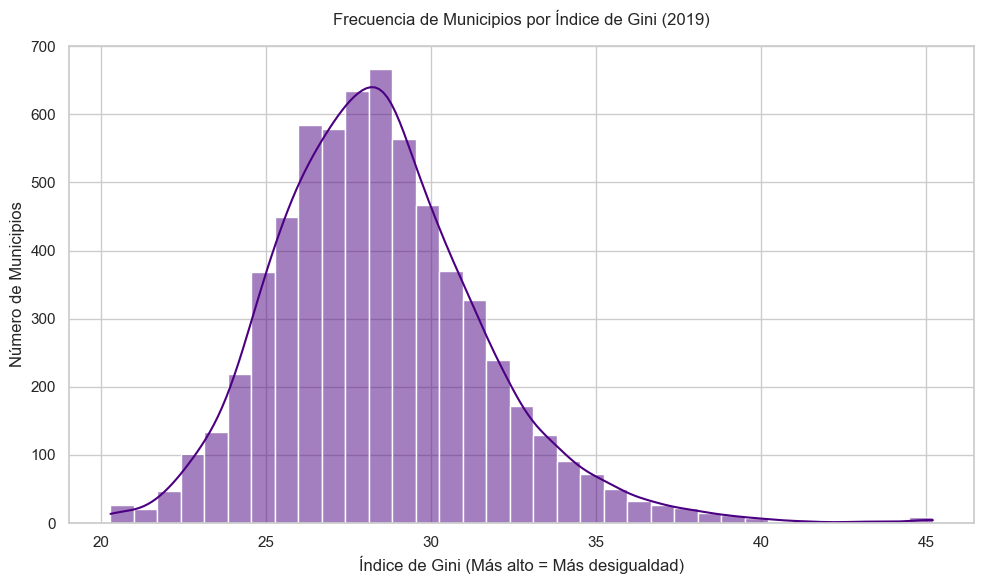

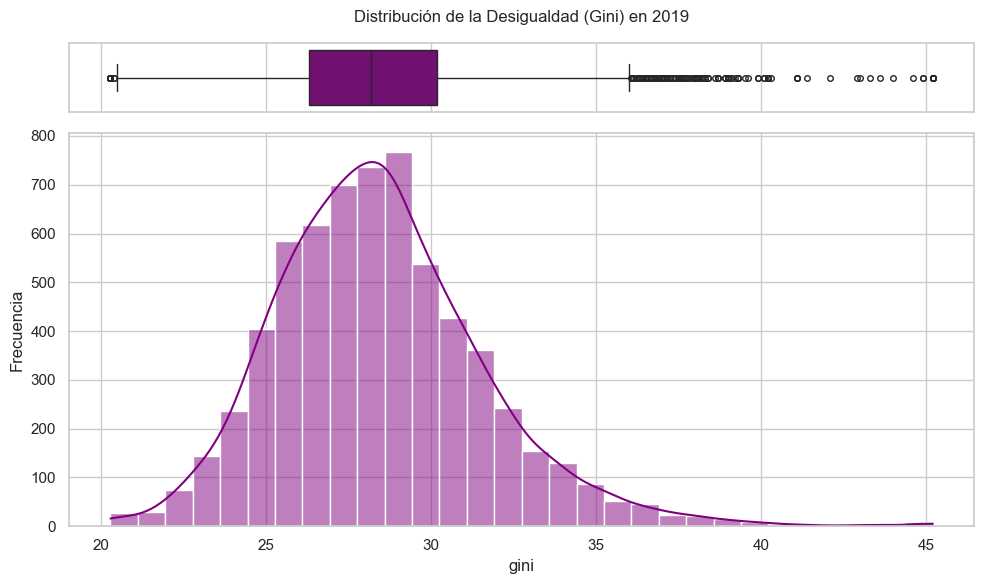

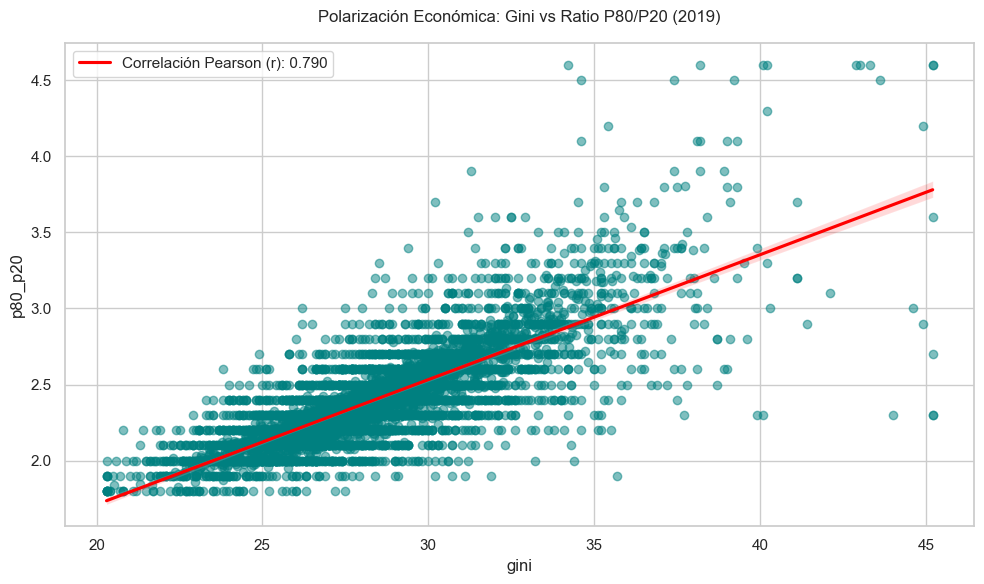

In [27]:
df_desigualdad_2019 = eda_gini_p80p20(df_gini_completo=df_2019_GINI_P80P20, anyo="2019")

Tras el procesamiento y visualización de los indicadores de renta relativos a 2019, se observa una radiografía de la desigualdad municipal que resulta determinante para entender el clima previo a los comicios. Para interpretar estos datos, es necesario precisar que el Índice de Gini es una medida de desigualdad que oscila entre 0 (igualdad total) y 100 (desigualdad máxima, donde una sola persona concentra toda la renta). En el contexto español, un Gini inferior a 25 se considera una cota de igualdad muy alta, el rango entre 28 y 32 representa el estándar medio nacional, y valores superiores a 35 o 40 indican una fractura social severa. Complementariamente, el Ratio P80/P20 cuantifica la polarización de los extremos, indicando cuántas veces superan los ingresos del 20% más rico de la población a los del 20% más pobre.

El análisis de distribución mediante el histograma confirma que la mayoría de los municipios españoles presentan una morfología de campana con una fuerte concentración en el intervalo de 26 a 31 puntos de Gini, lo que define la normalidad estadística de la desigualdad moderada en el país. Sin embargo, los resultados arrojan una sombra estadística significativa: 1.693 municipios (el 20,8% del total nacional) no presentan datos de renta. Este vacío no es aleatorio, sino que coincide con municipios de pequeño tamaño —la "España vaciada"— protegidos por el secreto estadístico del INE para preservar la privacidad en entornos de baja población. Esta ausencia de datos en el bloque de renta refuerza la tesis del desequilibrio territorial analizado en capítulos anteriores, donde la falta de visibilidad económica suele correlacionar con una marginalidad política que el sistema electoral intenta compensar.

En la gráfica se observa la relación entre ambas métricas, se ha obtenido un coeficiente de correlación de Pearson de $r = 0,790$. Este valor indica una correlación positiva fuerte, confirmando que la desigualdad en España se manifiesta de forma predominante como una polarización de los extremos. Matemáticamente, este resultado valida que en los municipios donde el Índice de Gini se eleva, la brecha social se ensancha de forma drástica y predecible: el enriquecimiento del bloque superior de renta ocurre de forma simultánea al estancamiento del bloque inferior. En localidades donde el Gini supera los 40 puntos, esta "fractura" social genera un entorno económico que suele traducirse en un ratio $P80/P20$ elevado (llegando a 4,6x en casos como Villarluengo).

Desde la perspectiva de este TFM, esta consistencia estadística ($r = 0,790$) sugiere que será importante observar si los los municipios situados en la parte alta de esta correlación, tienen comportamientos de voto dispares aquellos que ocupan la parte baja de la gráfica.ç

## distrivución de fuente de ingresos


==================== INICIANDO ANÁLISIS DE FUENTES DE INGRESOS (2019) ====================

AUDITORÍA DE DATOS FALTANTES FUENTES INGRESOS (2019)


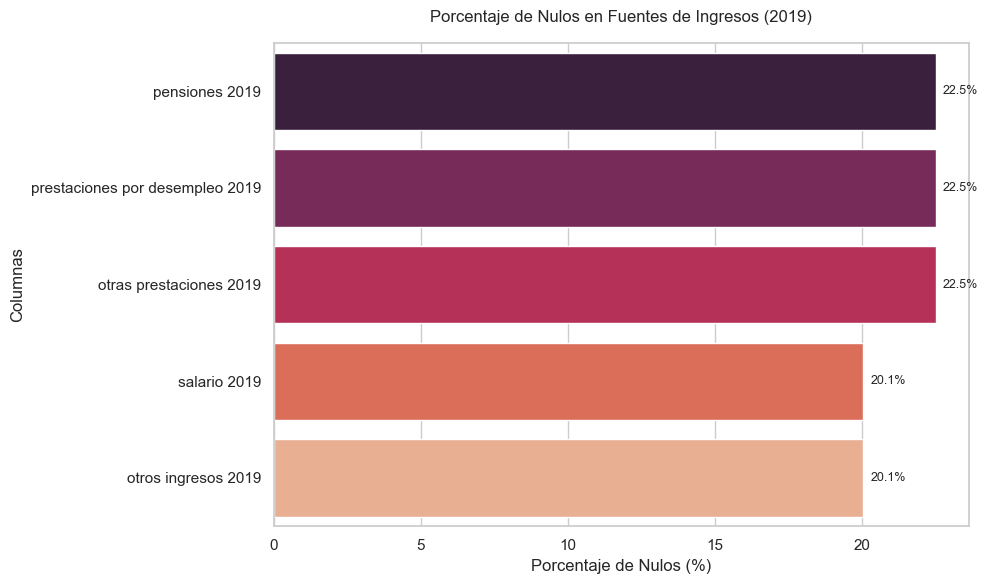

Nota: No se puede mostrar el perfil por tamaño de municipio para Fuentes Ingresos porque la columna no existe en los datos proporcionados.

IMPACTO POR PROVINCIA Fuentes Ingresos (2019)
Top 10 provincias con más nulos Fuentes Ingresos:
 - Navarra             :  211 municipios (13.0%)
 - Guadalajara         :  182 municipios (11.2%)
 - Burgos              :  171 municipios (10.5%)
 - Soria               :  118 municipios (7.3%)
 - Ávila               :  100 municipios (6.2%)
 - Teruel              :   96 municipios (5.9%)
 - Zaragoza            :   88 municipios (5.4%)
 - Salamanca           :   87 municipios (5.4%)
 - Segovia             :   79 municipios (4.9%)
 - Cuenca              :   78 municipios (4.8%)

RESUMEN NACIONAL: Peso Medio de las Fuentes de Ingresos (2019)
 - salario             : 52.6%
 - pensiones           : 26.9%
 - otros_ingresos      : 13.5%
 - otras_prestaciones  : 4.7%
 - desempleo           : 2.6%


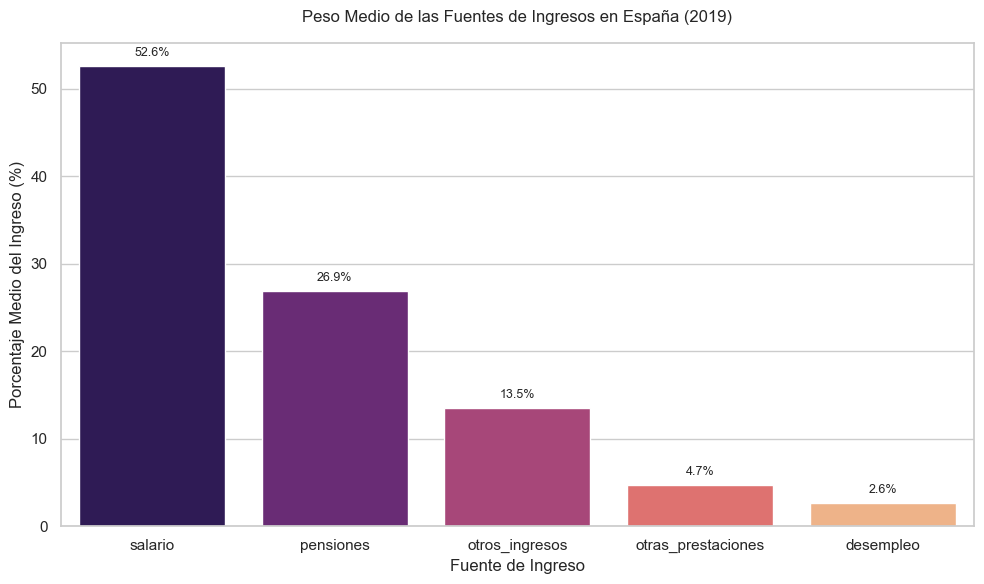

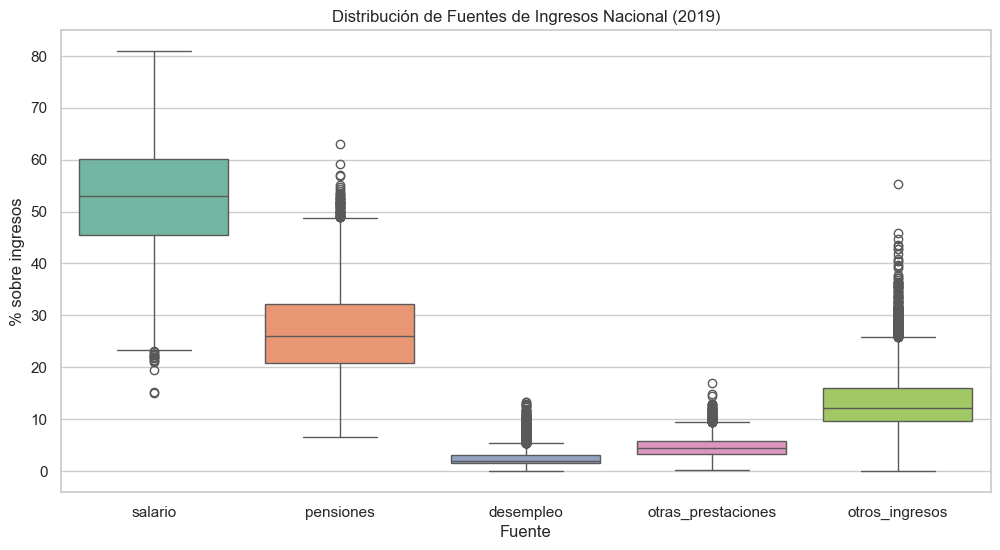


ANÁLISIS ESTRUCTURAL: Fuentes de Ingresos por Tamaño de Municipio (2019)


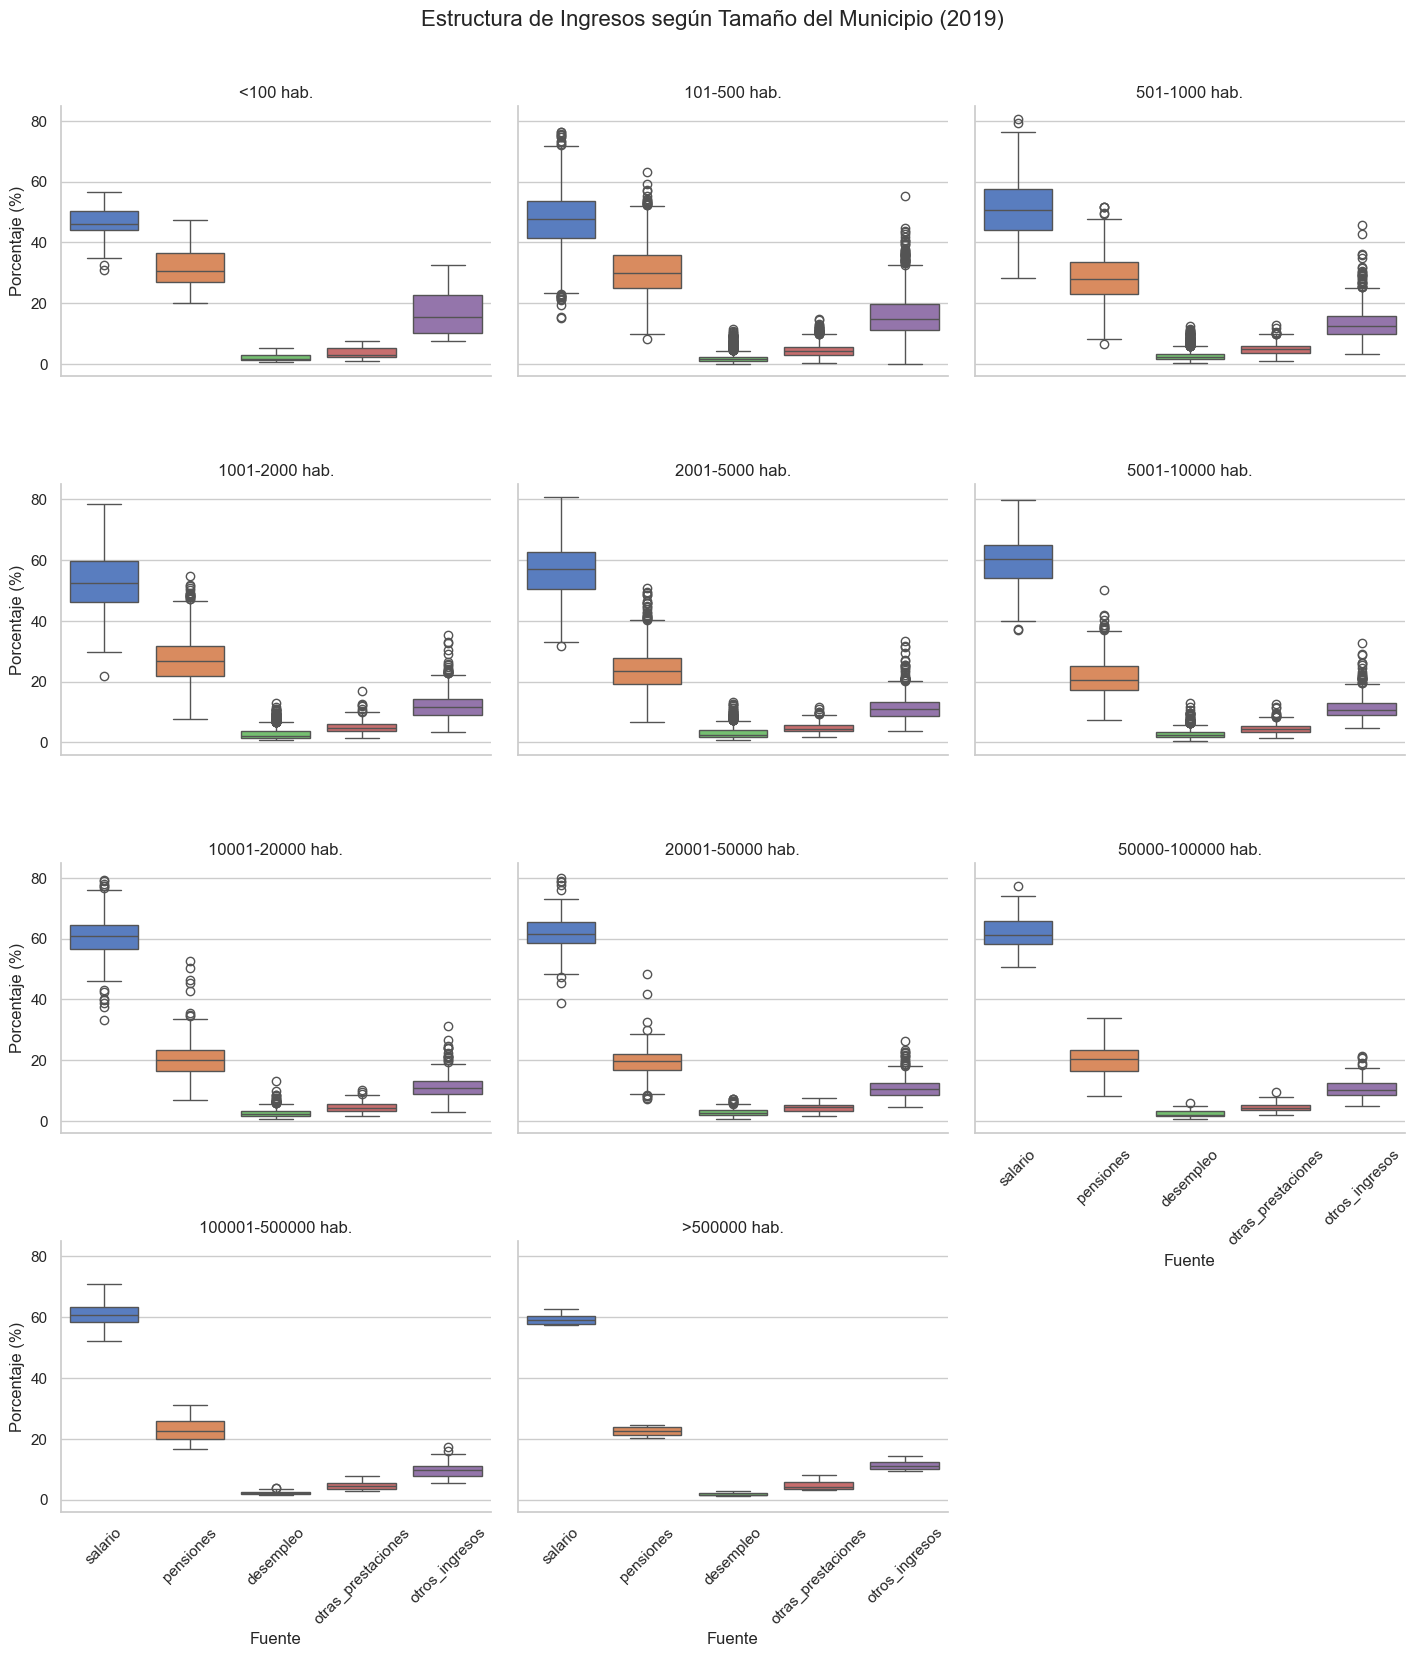

In [28]:
df_fuentes_2019 = eda_fuente_ingresos(df_2019_fuente_ingresos, df_2019_poblacion_csv, anyo="2019")

aa


--- INICIANDO ANÁLISIS DE INDICADORES DE RENTA (2019) ---

AUDITORÍA DE DATOS FALTANTES INDICADORES RENTA (2019)
Total de municipios en el dataset: 8139
Municipios sin datos de renta: 1582 (19.4%)


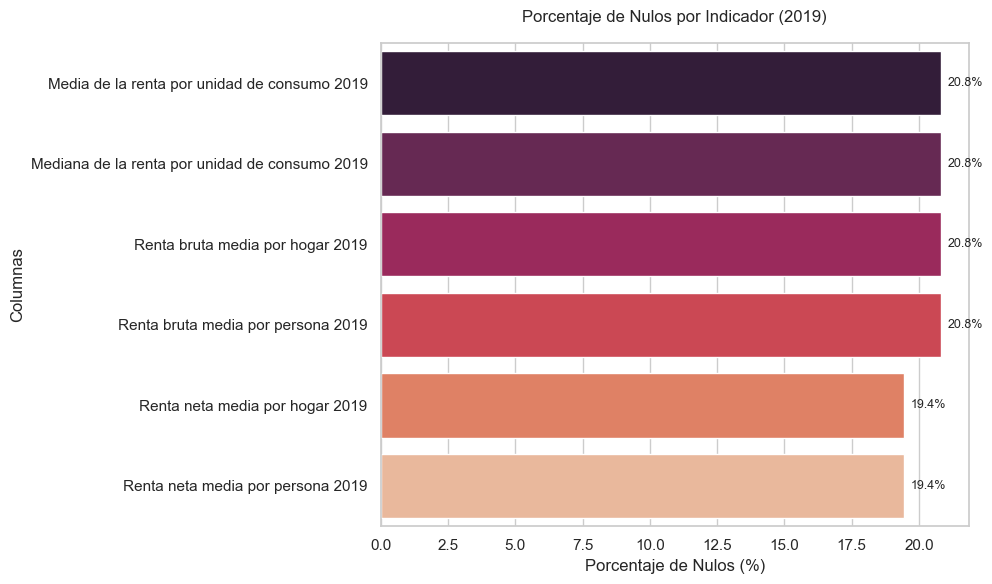

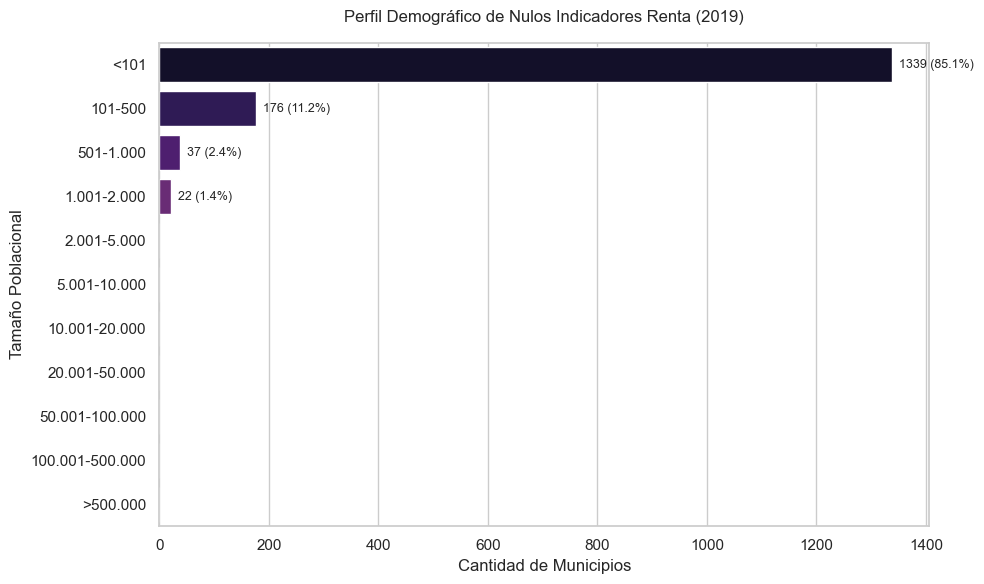


IMPACTO POR PROVINCIA Indicadores Renta (2019)
Top 10 provincias con más nulos Indicadores Renta:
 - Navarra             :  211 municipios (13.4%)
 - Guadalajara         :  182 municipios (11.6%)
 - Burgos              :  171 municipios (10.9%)
 - Soria               :  118 municipios (7.5%)
 - Ávila               :  100 municipios (6.4%)
 - Teruel              :   96 municipios (6.1%)
 - Zaragoza            :   88 municipios (5.6%)
 - Salamanca           :   87 municipios (5.5%)
 - Segovia             :   79 municipios (5.0%)
 - Cuenca              :   78 municipios (5.0%)


In [29]:
df_indicadores_renta_2019 = eda_indicadores_renta( df_renta_completo = df_2019_renta_disponible, df_pob = df_poblacion_superficie_2019, anyo = "2019")

El análisis de calidad revela que el 19,4% de los municipios (1.582 localidades) carece de datos de renta para el año 2019. Esta ausencia de información no responde a errores de registro, sino a la aplicación estricta del secreto estadístico por parte del INE, que busca proteger la privacidad de los ciudadanos en zonas donde la baja densidad de población permitiría identificar rentas individuales.

Demográficamente, este "apagón" informativo es absoluto en los estratos de municipios con menos de 1.000 habitantes, coincidiendo plenamente con el perfil de la España rural vaciada. Geográficamente, el impacto se concentra con especial dureza en Navarra (13,4% de los nulos), Guadalajara (11,6%) y Burgos (10,9%), seguidas por otras provincias con alta dispersión como Soria y Ávila.

Estos resultados demuestran que los indicadores de renta poseen un sesgo urbano intrínseco. Esto implica que, para casi el 20% del territorio nacional, precisamente el más envejecido, la renta no es un predictor electoral viable por falta de datos, lo que obliga a recurrir a variables alternativas para analizar su comportamiento en las urnas.


GENERANDO VISUALIZACIONES DE DISTRIBUCIÓN PARA 2019


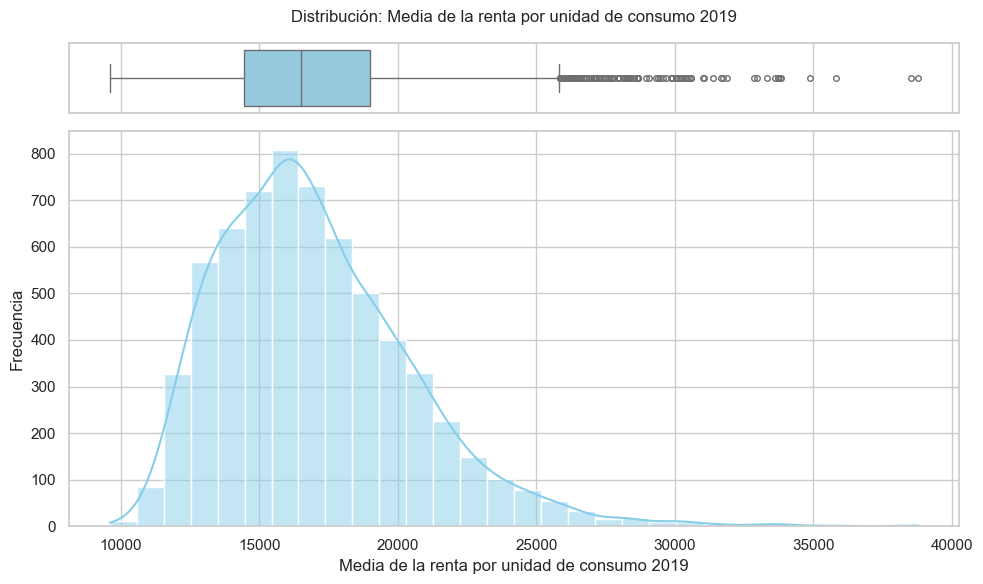

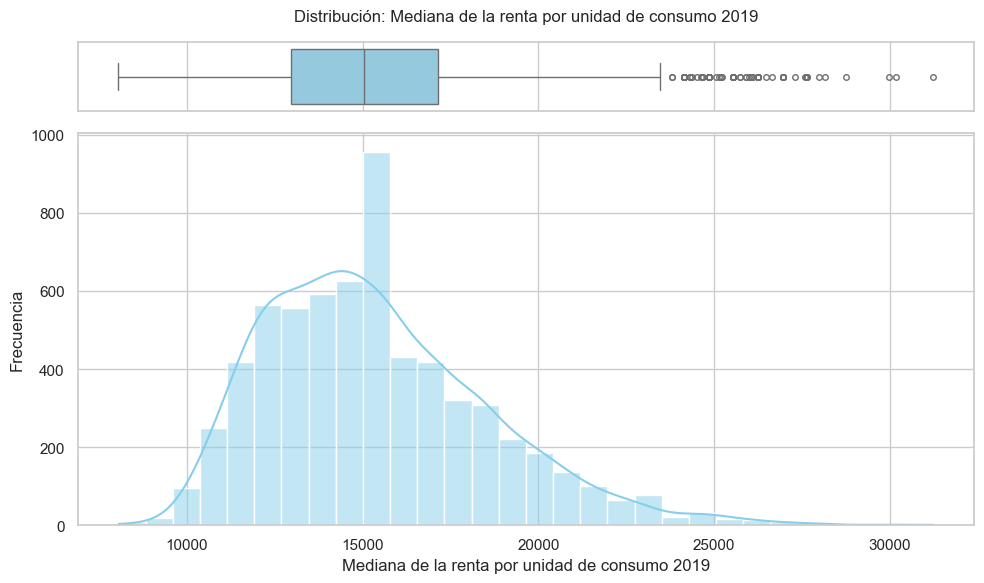

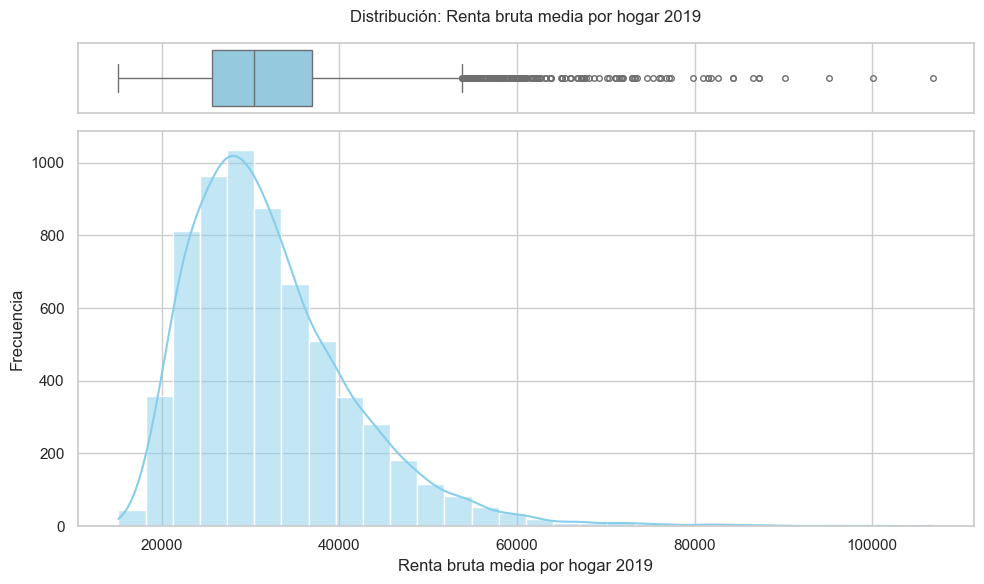

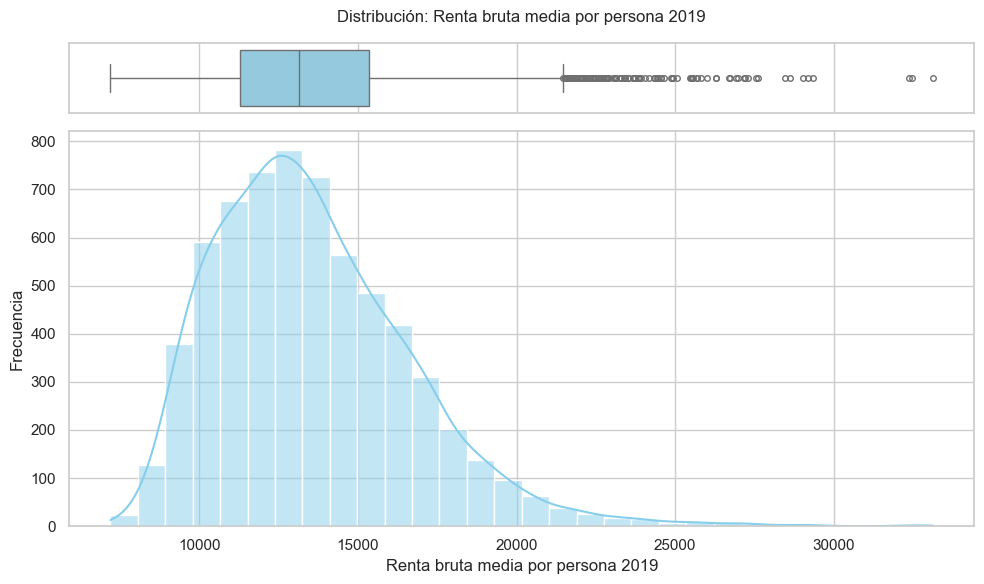

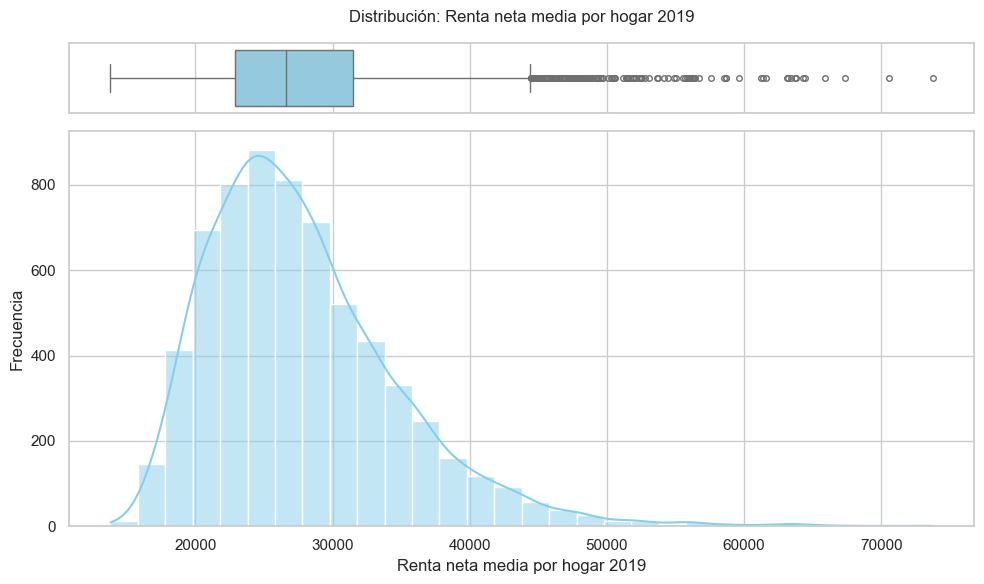

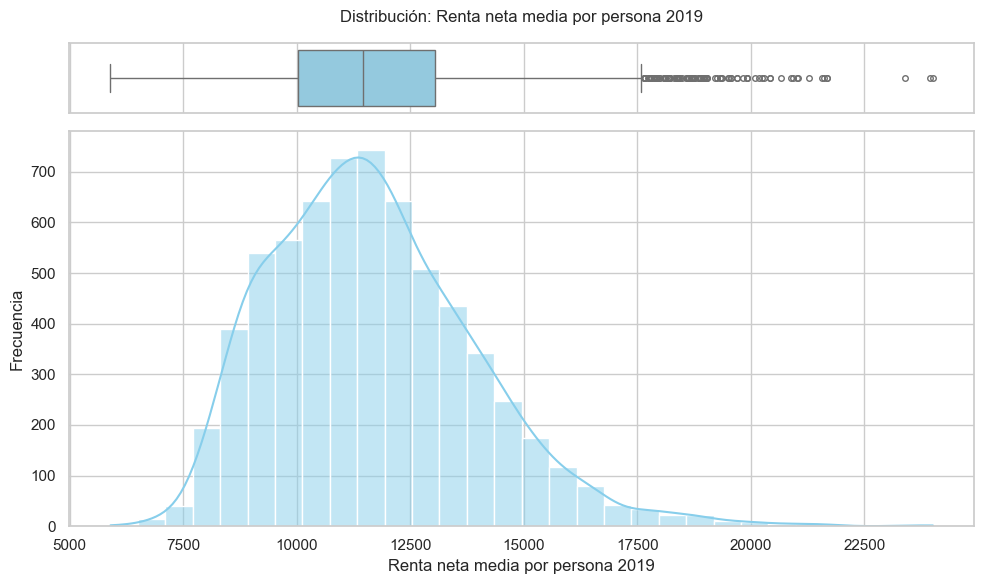

In [30]:
visualizar_histogramas_renta(df_indicadores_renta_2019, anyo="2019")

El análisis de la morfología de la renta en España revela una desigualdad estructural caracterizada por un marcado sesgo positivo. La distribución muestra una "larga cola" hacia la derecha, donde una minoría concentra ingresos excepcionalmente altos que distorsionan el promedio aritmético. Este fenómeno provoca que el ciudadano típico —representado por la moda— perciba ingresos significativamente inferiores a la media nacional, la cual se ve inflada por valores atípicos que llegan a cuadruplicar la mediana. Esta segregación geográfica de la riqueza sugiere la existencia de municipios que operan bajo una lógica económica totalmente aislada del comportamiento general del país.

Al comparar la renta bruta frente a la neta, se evidencia el impacto del sistema redistributivo. La transición hacia valores netos produce un desplazamiento de la curva hacia la izquierda y una compresión de la varianza, reduciendo la dispersión de los ingresos más altos. Mientras que la renta bruta por hogar se sitúa cerca de los 30.000€, la distribución neta se estrecha en torno a los 25.000€, acortando la distancia entre ellos. No obstante, el uso de la Unidad de Consumo (con un pico en los 16.000€) resulta ser la métrica más fiel para corregir las economías de escala de los hogares, mostrando una mayor homogeneidad en los niveles de vida reales en gran parte del territorio.

## Fase 2: Análisis del Target (Votos y Abstención)
Aquí es donde entiendes la "respuesta" que el modelo debe aprender.

2.1. Participación y Abstención
Acción: * %_Abstención = (Abstenciones / Censo_Electoral) * 100.
Análisis: * Busca si hay patrones geográficos. ¿Se vota menos en los municipios más pobres? ¿O en los más rurales?
* Identifica municipios con abstención extrema (>40%).

2.2. Concentración y Bloques
Acción: Agrupa los votos por Bloques Ideológicos (usando tu fichero de ideología).

* Bloque_Izquierda: PSOE + Sumar/Podemos + Regionalistas Izquierda.
* Bloque_Derecha: PP + VOX + Regionalistas Derecha.

Análisis:
* Dominancia: ¿En cuántos municipios el bloque de derecha supera el 60%? ¿Y el de izquierda?
* Fragmentación: ¿Cuántos partidos sacan más de un 5% en el mismo municipio? Esto te dirá dónde es más difícil predecir el escaño.

2.3. El fenómeno Regionalista
Acción: Analiza el peso de los partidos regionales que has sumado a los estatales.
* Análisis: ¿Hay provincias donde la suma de partidos regionales cambia el ganador del bloque? (Muy común en Cataluña o País Vasco).